# DM order with fixed pupil and WFS sampling

**Scientific question.** For the same physical turbulence realization and WFS
sampling, how does changing deformable-mirror actuator order affect a short
closed-loop residual and its RMS-based H-band Maréchal estimate?

The pupil grid, lenslet geometry, sensor, atmosphere, wind, frame times, and
controller settings are fixed across the order scan. Every configuration
uses the installed `shwfs_ao.control.run_closed_loop` engine, and an assertion
checks that the entire open-loop trajectory is identical across orders.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
    SPECTRUM_SUBHARMONIC_V2,
    TRANSLATION_FOURIER_SUBPIXEL_V2,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 1.5
WFS_WAVELENGTH_M = 700e-9
SCIENCE_WAVELENGTH_M = 1.65e-6
ORDERS = (5, 7) if FAST_SMOKE else (5, 7, 9)
N_STEPS = 6 if FAST_SMOKE else 14
# Hold the atmosphere grid and WFS sampling fixed within the order scan.
N_LENSLETS_ACROSS = max(ORDERS) + 1
PUPIL_PIXELS = 12 * N_LENSLETS_ACROSS


## Configuration

In [4]:
def build_system(n_across):
    lenslets = N_LENSLETS_ACROSS
    pixels = PUPIL_PIXELS
    geometry = build_shack_hartmann_geometry(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        pupil_shape=(pixels, pixels),
        n_lenslets_across=lenslets,
        min_fill_fraction=0.4,
    )
    optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
    sensor = build_detector_shack_hartmann_sensor(
        geometry,
        optics,
        DetectorConfig(photons_per_subap_frame=5e4),
        wfs_wavelength_m=WFS_WAVELENGTH_M,
        random_streams=NamedRandomStreams(SEED),
    )
    mirror = build_native_deformable_mirror(
        geometry.x_m,
        geometry.y_m,
        geometry.pupil_mask,
        DMConfig(
            telescope_diameter_m=TELESCOPE_DIAMETER_M,
            n_actuators_across=n_across,
            coupling_width_pitch=0.35,  # Synthetic narrow Gaussian basis (~1.7% coupling).
            stroke_limit_nm=20000.0,
        ),
    )
    interaction = calibrate_interaction_matrix(
        DmActuatorProbeBasis(mirror),
        sensor,
        amplitude_m=25e-9,
        random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
        include_noise=False,
    )
    atmosphere = FrozenFlowAtmosphere(
        FrozenFlowAtmosphereConfig(
            grid_size=geometry.pupil_shape[0],
            screen_grid_size=3 * geometry.pupil_shape[0],
            spectrum_model=SPECTRUM_SUBHARMONIC_V2,
            translation_model=TRANSLATION_FOURIER_SUBPIXEL_V2,
            normalize_rms=False,
            delta_m=geometry.pupil_geometry.pixel_spacing_xy_m[0],
            pupil_diameter_m=TELESCOPE_DIAMETER_M,
            r0_m=0.25,
            outer_scale_m=25.0,
            wind_m_per_s=(8.0, 0.0),
            root_seed=SEED,
        ),
        pupil_mask=geometry.pupil_mask,
    )
    return sensor, mirror, interaction, atmosphere


## Simulation call

In [5]:
def run_order(n_across):
    sensor, mirror, interaction, atmosphere = build_system(n_across)
    history = run_closed_loop(
        LoopConfig(
            n_steps=N_STEPS,
            gain=0.5,
            leak=0.0,
            latency_frames=1,
            frame_rate_hz=1000.0,
            root_seed=SEED,
        ),
        random_streams=NamedRandomStreams(SEED),
        atmosphere=atmosphere,
        wfs=sensor,
        dm=mirror,
        interaction_matrix=interaction,
        reconstructor=LeastSquaresReconstructor(
            interaction, min_valid_fraction=0.5, min_rank=1
        ),
        command_projector=IdentityCommandProjector(mirror.actuator_ids),
        controller=LeakyIntegratorController(
            mirror.actuator_ids, gain=0.5, leak=0.0, latency_frames=1
        ),
        include_noise=False,
        realization_index=0,
    )
    residual = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
    settled = float(np.mean(residual[N_STEPS // 2:]))
    open_trajectory = np.asarray(history.open_loop_opd_rms_m, dtype=float)
    open_loop = float(np.mean(open_trajectory[N_STEPS // 2:]))
    # Maréchal approximation: Strehl ~ exp(-(2 pi sigma / lambda)^2).
    strehl = float(np.exp(-((2 * np.pi * settled / SCIENCE_WAVELENGTH_M) ** 2)))
    assert np.isfinite(settled) and settled >= 0 and open_loop > 0
    assert 0 < strehl <= 1
    return settled, open_loop, strehl, int(mirror.n_actuators), open_trajectory

records = {order: run_order(order) for order in ORDERS}
reference_open = records[ORDERS[0]][4]
for order in ORDERS:
    np.testing.assert_allclose(records[order][4], reference_open, rtol=1e-12, atol=1e-18)


## Diagnostic table

In [6]:
table = pd.DataFrame(
    [
        (
            order,
            records[order][3],
            records[order][1] * 1e9,
            records[order][0] * 1e9,
            records[order][2],
        )
        for order in ORDERS
    ],
    columns=[
        "actuators across",
        "active actuators",
        "open-loop RMS, final half (nm)",
        "closed-loop RMS, final half (nm)",
        "H-band Maréchal estimate (RMS includes tilt)",
    ],
)
table

,actuators across,active actuators,"open-loop RMS, final half (nm)","closed-loop RMS, final half (nm)",H-band Maréchal estimate (RMS includes tilt)
0,5,13,256.292136,246.741812,0.413611
1,7,29,256.292136,229.561964,0.465719
2,9,49,256.292136,227.477198,0.472198


## Plot

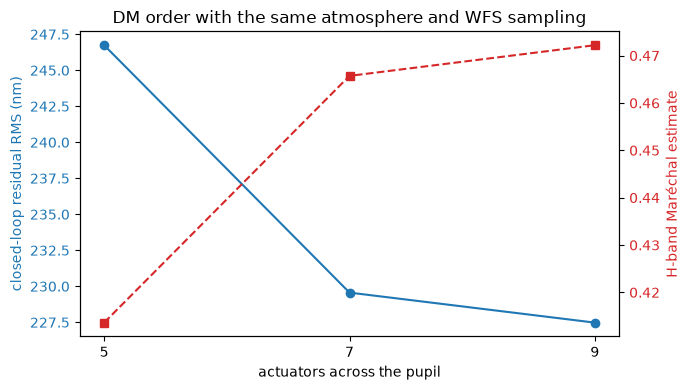

In [7]:
orders = list(ORDERS)
residual_nm = [records[o][0] * 1e9 for o in ORDERS]
strehl = [records[o][2] for o in ORDERS]
figure, left = plt.subplots(figsize=(7.0, 4.0))
left.plot(orders, residual_nm, "o-", color="C0", label="closed-loop RMS")
left.set_xlabel("actuators across the pupil")
left.set_xticks(orders)
left.set_ylabel("closed-loop residual RMS (nm)", color="C0")
left.tick_params(axis="y", labelcolor="C0")
right = left.twinx()
right.plot(orders, strehl, "s--", color="C3", label="H-band Strehl")
right.set_ylabel("H-band Maréchal estimate", color="C3")
right.tick_params(axis="y", labelcolor="C3")
left.set_title("DM order with the same atmosphere and WFS sampling")
figure.tight_layout()
plt.show()

## Interpretation

Each DM order now sees the same atmosphere on the same pupil grid and WFS
sampling, with the same wind, frame times, and controller settings. The
identical full open-loop trajectories are checked explicitly, so differences
between rows measure the effect of changing the mirror order and its
calibrated reconstructor within this system.

The mirror uses synthetic Gaussian influences with width `0.35 × pitch`
(about **1.7% neighbour coupling**). As actuator pitch changes, the physical
influence width changes with it. These bases are not nested; a monotonic
improvement is not guaranteed. Residuals include the basis's low-order
limitations, WFS reconstruction, and temporal tracking as well as uncorrected
high spatial frequencies. The scan therefore does not by itself measure a
classical high-order fitting coefficient.

## Limitations

- Open- and closed-loop means use the same final-half window of a short run.
  Multiple seeds and longer runs are needed for performance claims.
- The H-band value is a small-error Maréchal estimate derived from RMS that
  includes tip/tilt. It is not a propagated, peak-recentered PSF Strehl.
- WFS noise is disabled. The fixed sensor sampling must still resolve the
  modes commanded at each mirror order.
- `noise_latency_gain.ipynb` is a noiseless control scan;
  `detector_level_2m.ipynb` includes photon and read noise under different
  system parameters.
